In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import cm
from qiskit.circuit.library import CXGate, SwapGate, iSwapGate
from weylchamber import WeylChamber
from hetero_isas.zz_parallel_drive.ansatz import BasicCircuitAnsatz
from hetero_isas.numerical_decomp import (
    CircuitAnsatzDecomposer,
    ClosestInvariantSearch,
)
import numpy as np
from qiskit.circuit.library import UnitaryGate

In [ ]:
# NOTE I have deprecated pretty much all of this behavior in favor
# of rewriting numerical_decomp.py to make assumptions about the form of the PQC
# :)

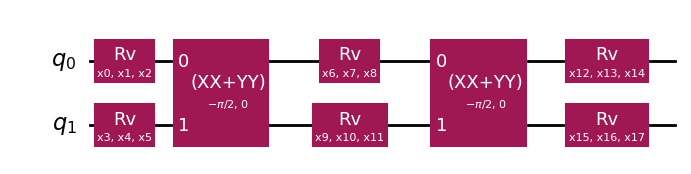

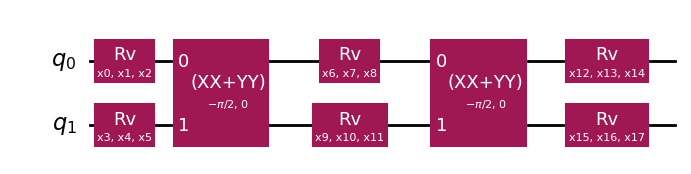

In [2]:
ansatz = BasicCircuitAnsatz(
    basis_gate=iSwapGate().power(1 / 2),
    num_layers=2,
    outside_layer_u=(3, 3),
)
ansatz.qc.draw("mpl")

In [4]:
decomposer = CircuitAnsatzDecomposer(ansatz)
decomposer.allow_fail = True
output_qc = decomposer(CXGate())
output_qc.draw("mpl")

/home/evm9/dev_workspace/src/hetero_isas/numerical_decomp.py:156: UserWarning: using this decomposer is pointless :)                       that is because you can get the exterior 1Q gates using KAK instead.
  warnings.warn(


In [15]:
# Should raise RuntimeError :)
# output_qc = decomposer(SwapGate())
# output_qc.draw("mpl");

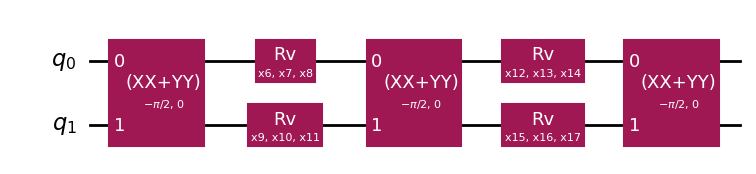

In [22]:
ansatz = BasicCircuitAnsatz(basis_gate=iSwapGate().power(1 / 2), num_layers=3)
ansatz.qc.draw("mpl")

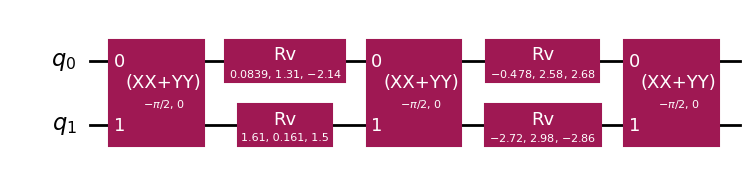

In [23]:
decomposer = ClosestInvariantSearch(ansatz)
output_qc = decomposer(CXGate())
output_qc.draw("mpl")

In [24]:
output_qc = decomposer(SwapGate())
output_qc.draw("mpl");

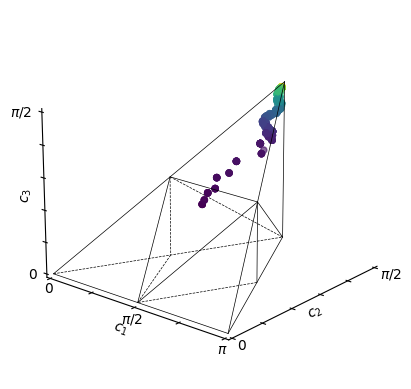

In [25]:
# callback method in ClosestInvariantSearch saves the intermediate points
ax = plt.subplot(111, projection="3d", computed_zorder=False)
idx = 2
colors = cm.viridis(np.linspace(0, 1.0, len(ansatz.weyl_coords[idx])))
w = WeylChamber()
w.labels = {}
w.render(ax)
w.ax.scatter3D(*zip(*ansatz.weyl_coords[idx]), color=colors, zorder=-1);